<div style="background-color:#EAF4EC; padding:20px; border-radius:10px;">

<h2 style="color:#2F6F4E; text-align:center; margin-bottom:5px;">
Fuzzy Clustering: Governance Typologies
</h2>

<h4 style="color:#2F6F4E; text-align:center; margin-top:0;">
Master Thesis – ESG Governance Indicators (EU-27)
</h4>

<p style="font-size:14px; color:#2F6F4E;">
This notebook applies a <strong>Fuzzy C-Means clustering approach</strong> to identify governance typologies
across the EU-27 based on the forecasted ESG governance indicators.
</p>

<p style="font-size:14px; color:#2F6F4E;">
Unlike traditional hard clustering methods, fuzzy clustering allows each country to
have <strong>partial membership across multiple clusters</strong>, capturing the gradual and evolving
nature of institutional and governance development across European economies.
</p>

<p style="font-size:14px; color:#2F6F4E;">
The clustering analysis is conducted using the consolidated dataset covering the period
<strong>2000–2030</strong>, combining observed data and machine learning forecasts.
The resulting clusters represent distinct governance typologies that form the basis for
subsequent analysis of <strong>structural transitions and convergence patterns</strong> among EU member states.
</p>

</div>

In [2]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import f_oneway
from sklearn.metrics import silhouette_score
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA

custom_cmap = LinearSegmentedColormap.from_list(
    "gov_corr",
    ["#8B1E3F", "#EAF4EC", "#2F6F4E"],   # vermelho → neutro → verde
    N=256
)
BG             = "#EAF4EC"
ACCENT         = "#2F6F4E"
TEXT           = "#1F2937"
CLUSTER_COLORS = ["#B7E4C7", "#6FBF9B", "#2F6F4E"]

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
1. Import the dataset

</div>

In [3]:
df_final = pd.read_csv("../../data/processed/final_forecast_2000_2030_scaled.csv")

print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
print("Years:", sorted(df_final["year"].unique()))
df_final.head()

Shape: (12555, 9)
Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', 'year', 'value', 'type', 'Best_Model', 'value_scaled']
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030)]


,Country Name,Country Code,Indicator Name,Indicator Code,year,value,type,Best_Model,value_scaled
0,Austria,AUT,"School enrollment, primary and secondary (gros...",SE.ENR.PRSC.FM.ZS,2000,0.96969,observed,RF,-1.302044
1,Austria,AUT,"School enrollment, primary and secondary (gros...",SE.ENR.PRSC.FM.ZS,2001,0.96958,observed,RF,-1.306009
2,Austria,AUT,"School enrollment, primary and secondary (gros...",SE.ENR.PRSC.FM.ZS,2002,0.96443,observed,RF,-1.491598
3,Austria,AUT,"School enrollment, primary and secondary (gros...",SE.ENR.PRSC.FM.ZS,2003,0.96342,observed,RF,-1.527995
4,Austria,AUT,"School enrollment, primary and secondary (gros...",SE.ENR.PRSC.FM.ZS,2004,0.96304,observed,RF,-1.541688


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
2. PIVOT: country-year x indicator

</div>

In [4]:
INDICATOR_COLS = sorted(df_final["Indicator Code"].unique().tolist())

df_xy = df_final.pivot_table(
    index=["Country Code", "Country Name", "year"],
    columns="Indicator Code",
    values="value_scaled",
    aggfunc="mean"
).reset_index()

print("Shape pivot:", df_xy.shape)
df_xy.head()

Shape pivot: (837, 18)


Indicator Code,Country Code,Country Name,year,CC.EST,GB.XPD.RSDV.GD.ZS,GE.EST,IP.JRN.ARTC.SC,IP.PAT.RESD,IT.NET.USER.ZS,NY.GDP.MKTP.KD.ZG,PV.EST,RL.EST,RQ.EST,SE.ENR.PRSC.FM.ZS,SG.GEN.PARL.ZS,SL.TLF.CACT.FM.ZS,SM.POP.NETM,VA.EST
0,AUT,Austria,2000,1.019055,0.349625,1.377291,-0.483511,-0.146078,-1.540189,0.185411,0.246090,1.262770,0.740054,-1.302044,-0.009062,-1.053277,-0.192420,0.629646
1,AUT,Austria,2001,1.019055,0.466785,1.377291,-0.465781,-0.162936,-1.315214,-0.357398,0.246090,1.262770,0.740054,-1.306009,-0.009062,-0.937741,-0.019011,0.629646
2,AUT,Austria,2002,1.231648,0.548381,1.433267,-0.449053,-0.149426,-1.421566,-0.308877,1.700920,1.339214,0.873200,-1.491598,-0.009062,-0.728178,-0.037401,0.600535
3,AUT,Austria,2003,1.294752,0.668302,1.518571,-0.430997,-0.127718,-1.172049,-0.408249,0.625301,1.322450,0.871242,-1.527995,0.667780,-0.699278,0.016053,0.705798
4,AUT,Austria,2004,1.376052,0.658980,1.371357,-0.423844,-0.112938,-0.697557,0.004449,0.971184,1.270034,0.822237,-1.541688,0.667780,-0.423869,0.099072,1.087009


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
3. Selecting the Number of Clustering

</div>

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
N_CLUSTERS with FPC

</div>

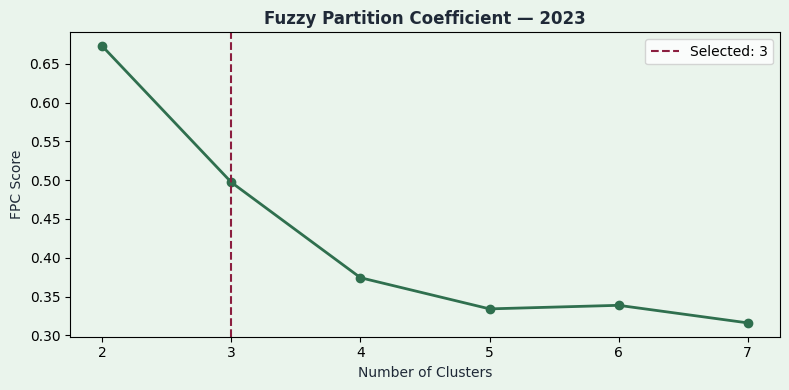

FPC scores: {2: np.float64(0.6728), 3: np.float64(0.4972), 4: np.float64(0.3743), 5: np.float64(0.3341), 6: np.float64(0.3387), 7: np.float64(0.316)}


In [5]:
df_ref = df_xy[df_xy["year"] == 2023][INDICATOR_COLS].values.astype(float)
col_means = np.nanmean(df_ref, axis=0)
inds = np.where(np.isnan(df_ref))
df_ref[inds] = np.take(col_means, inds[1])
X_ref = StandardScaler().fit_transform(df_ref)

n_range = range(2, 8)
fpcs = []

for c in n_range:
    _, u, *_ = fuzz.cluster.cmeans(X_ref.T, c=c, m=2, error=0.005, maxiter=1000, init=None)
    fpcs.append(np.sum(u**2) / u.shape[1])

plt.figure(figsize=(8, 4), facecolor=BG)
ax = plt.gca()
ax.set_facecolor(BG)

plt.plot(n_range, fpcs, "o-", color="#2F6F4E", lw=2)
plt.axvline(3, color="#8B1E3F", linestyle="--", label="Selected: 3")

plt.xlabel("Number of Clusters", color=TEXT)
plt.ylabel("FPC Score", color=TEXT)
plt.title("Fuzzy Partition Coefficient — 2023", color=TEXT, fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

print("FPC scores:", dict(zip(n_range, [round(f, 4) for f in fpcs])))

Although FPC peaks at c=2, three clusters were selected to preserve interpretability and allow for a meaningful differentiation between governance performance levels across EU-27 member states.

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
N_CLUSTERS with Silhouette Score

</div>

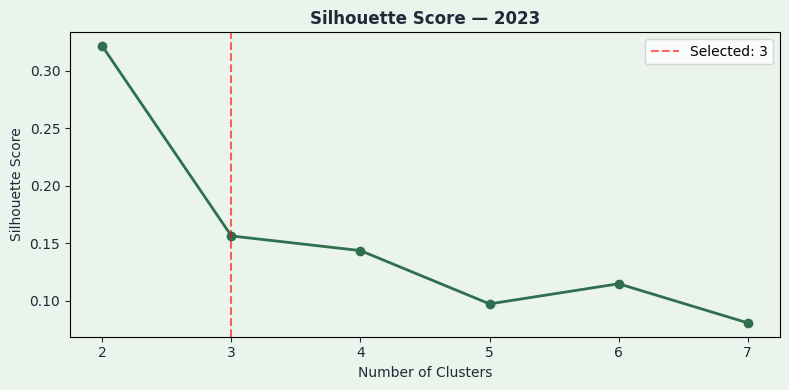

Silhouette scores: {2: 0.3215, 3: 0.1563, 4: 0.1436, 5: 0.0972, 6: 0.1147, 7: 0.0807}


In [6]:
sil_scores = []
k_range    = range(2, 8)

for k in k_range:
    _, u, *_ = fuzz.cluster.cmeans(
        X_ref.T, c=k, m=2,
        error=0.005, maxiter=1000, init=None
    )
    labels = np.argmax(u, axis=0)
    sil_scores.append(silhouette_score(X_ref, labels))

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor(BG)
ax.plot(list(k_range), sil_scores, "o-", color=ACCENT, lw=2)
ax.axvline(x=3, color="red", linestyle="--", alpha=0.6, label="Selected: 3")
ax.set_xlabel("Number of Clusters", color=TEXT)
ax.set_ylabel("Silhouette Score", color=TEXT)
ax.set_title("Silhouette Score — 2023", color=TEXT, fontweight="bold")
ax.tick_params(colors=TEXT)
ax.legend()
plt.tight_layout()
plt.show()

print("Silhouette scores:", dict(zip(k_range, [round(s, 4) for s in sil_scores])))

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
N_CLUSTERS with Davies-Bouldin Index

</div>

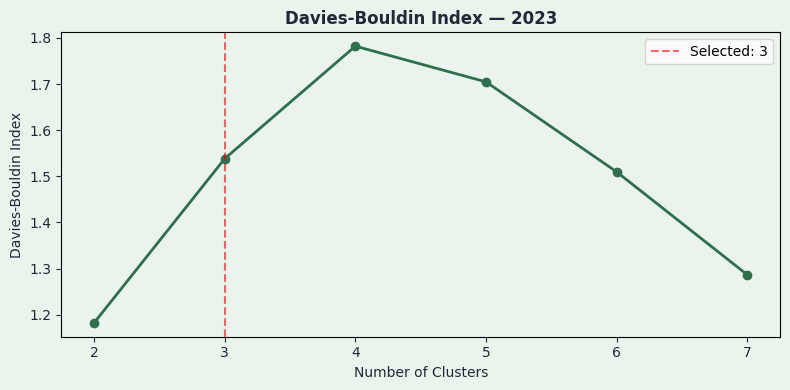

Davies-Bouldin scores: {2: 1.1821, 3: 1.5383, 4: 1.7822, 5: 1.7048, 6: 1.5096, 7: 1.2864}


In [7]:
db_scores = []

for k in k_range:
    _, u, *_ = fuzz.cluster.cmeans(
        X_ref.T, c=k, m=2,
        error=0.005, maxiter=1000, init=None
    )
    labels = np.argmax(u, axis=0)
    db_scores.append(davies_bouldin_score(X_ref, labels))

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor(BG)
ax.plot(list(k_range), db_scores, "o-", color=ACCENT, lw=2)
ax.axvline(x=3, color="red", linestyle="--", alpha=0.6, label="Selected: 3")
ax.set_xlabel("Number of Clusters", color=TEXT)
ax.set_ylabel("Davies-Bouldin Index", color=TEXT)
ax.set_title("Davies-Bouldin Index — 2023", color=TEXT, fontweight="bold")
ax.tick_params(colors=TEXT)
ax.legend()
plt.tight_layout()
plt.show()

print("Davies-Bouldin scores:", dict(zip(k_range, [round(s, 4) for s in db_scores])))

##### Why k=3 is still justified?
k=2 produces a binary split that loses all the nuance of institutional transition across EU countries. k=3 introduces an intermediate cluster that captures countries in transitional governance states, which is the core analytical interest of this study.
The FPC value of 0.50 at k=3 is acceptable, and the sharpest elbow in the FPC curve occurs precisely between k=2 and k=3, supporting this as a meaningful partition boundary. Beyond k=3, no metric shows meaningful improvement.
k=3 is the minimum number of clusters that produces a theoretically interpretable governance typology.

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
4. Fuzzy C-Means Clustering with Temporal Alignment
</div>

In [8]:
N_CLUSTERS = 3
M          = 2
all_years  = sorted(df_xy["year"].unique())
results    = []
u_ref      = None

for y in all_years:
    df_y = df_xy[df_xy["year"] == y].copy().reset_index(drop=True)
    if df_y.empty:
        continue

    # preparar matrix X
    X = df_y[INDICATOR_COLS].values.astype(float)
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    X_scaled = StandardScaler().fit_transform(X)

    # fuzzy c-means
    cntr, u, *_ = fuzz.cluster.cmeans(
        X_scaled.T, c=N_CLUSTERS, m=M,
        error=0.005, maxiter=1000, init=None
    )

    # alinhamento temporal com algoritmo húngaro
    if u_ref is not None:
        overlap  = u_ref @ u.T
        _, col_ind = linear_sum_assignment(-overlap)
        u = u[col_ind, :]

    u_ref = u.copy()

    # guardar resultados
    cluster_labels = np.argmax(u, axis=0)
    row = df_y[["Country Code", "Country Name"]].copy()
    row["year"]    = y
    row["Cluster"] = cluster_labels
    for k in range(N_CLUSTERS):
        row[f"Membership_{k}"] = u[k, :]

    results.append(row)

fuzzy_all = pd.concat(results, ignore_index=True)
fuzzy_all["Max_Membership"] = fuzzy_all[[f"Membership_{k}" for k in range(N_CLUSTERS)]].max(axis=1)
fuzzy_all["Ambiguous"]      = fuzzy_all["Max_Membership"] < 0.6

print("Shape fuzzy_all:", fuzzy_all.shape)
fuzzy_all.head(26)


Shape fuzzy_all: (837, 9)


Indicator Code,Country Code,Country Name,year,Cluster,Membership_0,Membership_1,Membership_2,Max_Membership,Ambiguous
0,AUT,Austria,2000,1,0.116616,0.544235,0.339150,0.544235,True
1,BEL,Belgium,2000,1,0.106853,0.483762,0.409386,0.483762,True
2,BGR,Bulgaria,2000,0,0.827277,0.050650,0.122073,0.827277,False
3,CYP,Cyprus,2000,2,0.337257,0.089850,0.572893,0.572893,True
4,CZE,Czechia,2000,0,0.905505,0.020102,0.074393,0.905505,False
5,DEU,Germany,2000,1,0.221257,0.420682,0.358061,0.420682,True
6,DNK,Denmark,2000,1,0.030965,0.897463,0.071572,0.897463,False
7,ESP,Spain,2000,2,0.188142,0.265829,0.546030,0.546030,True
8,EST,Estonia,2000,2,0.343979,0.164437,0.491584,0.491584,True
9,FIN,Finland,2000,1,0.053849,0.832381,0.113771,0.832381,False


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
5. PCA 2D
</div>

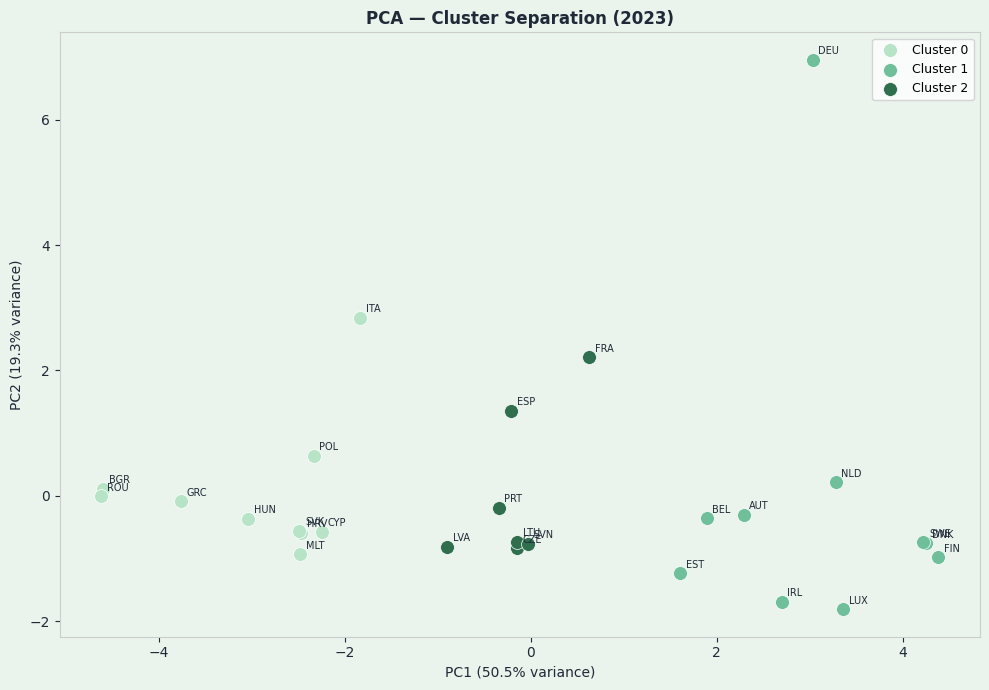

Variance explained: PC1=50.5% | PC2=19.3% | Total=69.8%


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_ref)

labels_2023 = fuzzy_all[fuzzy_all["year"] == 2023]["Cluster"].values
countries = fuzzy_all[fuzzy_all["year"] == 2023]["Country Code"].values

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)

for k, color, name in zip([0, 1, 2], CLUSTER_COLORS, ["Cluster 0", "Cluster 1", "Cluster 2"]):
    mask = labels_2023 == k
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=color,
        label=name,
        s=100,
        edgecolors="white",
        linewidth=0.5
    )
    for i, code in enumerate(countries[mask]):
        ax.annotate(
            code,
            (X_pca[mask, 0][i], X_pca[mask, 1][i]),
            fontsize=7,
            color=TEXT,
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", color=TEXT)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", color=TEXT)
ax.set_title("PCA — Cluster Separation (2023)", color=TEXT, fontweight="bold")
ax.legend(fontsize=9)
ax.tick_params(colors=TEXT)

for spine in ax.spines.values():
    spine.set_color("#cccccc")

plt.tight_layout()
plt.show()

print(
    f"Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}% | "
    f"PC2={pca.explained_variance_ratio_[1]*100:.1f}% | "
    f"Total={sum(pca.explained_variance_ratio_)*100:.1f}%"
)

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
6. Visual Validation of the Clustering Solution
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
PCA projection of the 2023 clustering structure
</p>
</div>

In [10]:
df_profile = df_xy.merge(
    fuzzy_all[["Country Code", "year", "Cluster", "Ambiguous"]],
    on=["Country Code", "year"],
    how="inner"
)

print("Shape df_profile:", df_profile.shape)
df_profile.head()

Shape df_profile: (837, 20)


Indicator Code,Country Code,Country Name,year,CC.EST,GB.XPD.RSDV.GD.ZS,GE.EST,IP.JRN.ARTC.SC,IP.PAT.RESD,IT.NET.USER.ZS,NY.GDP.MKTP.KD.ZG,PV.EST,RL.EST,RQ.EST,SE.ENR.PRSC.FM.ZS,SG.GEN.PARL.ZS,SL.TLF.CACT.FM.ZS,SM.POP.NETM,VA.EST,Cluster,Ambiguous
0,AUT,Austria,2000,1.019055,0.349625,1.377291,-0.483511,-0.146078,-1.540189,0.185411,0.246090,1.262770,0.740054,-1.302044,-0.009062,-1.053277,-0.192420,0.629646,1,True
1,AUT,Austria,2001,1.019055,0.466785,1.377291,-0.465781,-0.162936,-1.315214,-0.357398,0.246090,1.262770,0.740054,-1.306009,-0.009062,-0.937741,-0.019011,0.629646,1,True
2,AUT,Austria,2002,1.231648,0.548381,1.433267,-0.449053,-0.149426,-1.421566,-0.308877,1.700920,1.339214,0.873200,-1.491598,-0.009062,-0.728178,-0.037401,0.600535,1,True
3,AUT,Austria,2003,1.294752,0.668302,1.518571,-0.430997,-0.127718,-1.172049,-0.408249,0.625301,1.322450,0.871242,-1.527995,0.667780,-0.699278,0.016053,0.705798,1,True
4,AUT,Austria,2004,1.376052,0.658980,1.371357,-0.423844,-0.112938,-0.697557,0.004449,0.971184,1.270034,0.822237,-1.541688,0.667780,-0.423869,0.099072,1.087009,1,False


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Mean indicator values by cluster in 2000
</p>
</div>

In [11]:
for year_focus in [2000]:
    df_yr = df_profile[
        (df_profile["year"] == year_focus) &
        (df_profile["Ambiguous"] == False)
    ]

    profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()
    profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]

    print(f"\n{'='*60}")
    print(f"CLUSTER PROFILES — {year_focus}")
    print(f"{'='*60}")
    print(profile.T.round(3).to_string())


CLUSTER PROFILES — 2000
Cluster                0      1      2
CC EST            -1.141  1.683  0.238
GB XPD RSDV GD    -1.000  1.329 -0.936
GE EST            -1.276  1.547 -0.108
IP JRN ARTC SC    -0.608 -0.274 -0.611
IP PAT RESD       -0.301 -0.055 -0.363
IT NET USER       -2.638 -1.220 -2.248
NY GDP MKTP KD ZG  0.301  0.589  0.367
PV EST            -1.157  2.335  1.798
RL EST            -1.447  1.287  0.236
RQ EST            -1.492  1.254 -0.444
SE ENR PRSC FM    -0.170  1.523  0.182
SG GEN PARL       -1.229  1.075 -0.903
SL TLF CACT FM    -0.397  0.539 -0.468
SM POP NETM       -0.535 -0.141  0.143
VA EST            -1.112  1.336  0.746


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Mean indicator values by cluster in 2023
</p>
</div>

In [12]:
for year_focus in [2023]:
    df_yr = df_profile[
        (df_profile["year"] == year_focus) &
        (df_profile["Ambiguous"] == False)
    ]

    profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()
    profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]

    print(f"\n{'='*60}")
    print(f"CLUSTER PROFILES — {year_focus}")
    print(f"{'='*60}")
    print(profile.T.round(3).to_string())


CLUSTER PROFILES — 2023
Cluster                0      1      2
CC EST            -1.064  1.245 -0.293
GB XPD RSDV GD    -0.532  1.156 -0.183
GE EST            -1.441  1.133 -0.158
IP JRN ARTC SC    -0.204 -0.091 -0.464
IP PAT RESD       -0.271 -0.209 -0.340
IT NET USER        0.624  1.033  0.731
NY GDP MKTP KD ZG -0.343 -0.746 -0.165
PV EST            -0.708  0.170 -0.041
RL EST            -1.181  1.192  0.074
RQ EST            -1.333  1.290 -0.273
SE ENR PRSC FM    -0.569  0.443 -0.290
SG GEN PARL       -0.469  1.415  0.637
SL TLF CACT FM    -0.251  1.161  0.664
SM POP NETM       -0.506  0.034 -0.160
VA EST            -1.348  1.385 -0.033


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Mean indicator values by cluster in 2030
</p>
</div>

In [13]:
for year_focus in [2030]:
    df_yr = df_profile[
        (df_profile["year"] == year_focus) &
        (df_profile["Ambiguous"] == False)
    ]

    profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()
    profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]

    print(f"\n{'='*60}")
    print(f"CLUSTER PROFILES — {year_focus}")
    print(f"{'='*60}")
    print(profile.T.round(3).to_string())


CLUSTER PROFILES — 2030
Cluster                0      1      2
CC EST            -1.070  1.120 -0.334
GB XPD RSDV GD    -0.591  1.283  0.229
GE EST            -1.371  0.803 -0.087
IP JRN ARTC SC    -0.381  0.098 -0.262
IP PAT RESD       -0.337 -0.247 -0.330
IT NET USER        0.813  1.008  0.827
NY GDP MKTP KD ZG  0.237  0.174  0.177
PV EST            -1.055  0.095  0.011
RL EST            -1.153  1.145  0.037
RQ EST            -1.297  1.246 -0.320
SE ENR PRSC FM    -0.556  0.718 -0.157
SG GEN PARL       -0.468  1.316  0.452
SL TLF CACT FM     0.138  1.127  0.659
SM POP NETM       -0.295 -0.193 -0.192
VA EST            -1.006  1.250 -0.185


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Heatmap of average indicator values by cluster in 2000
</p>
</div>

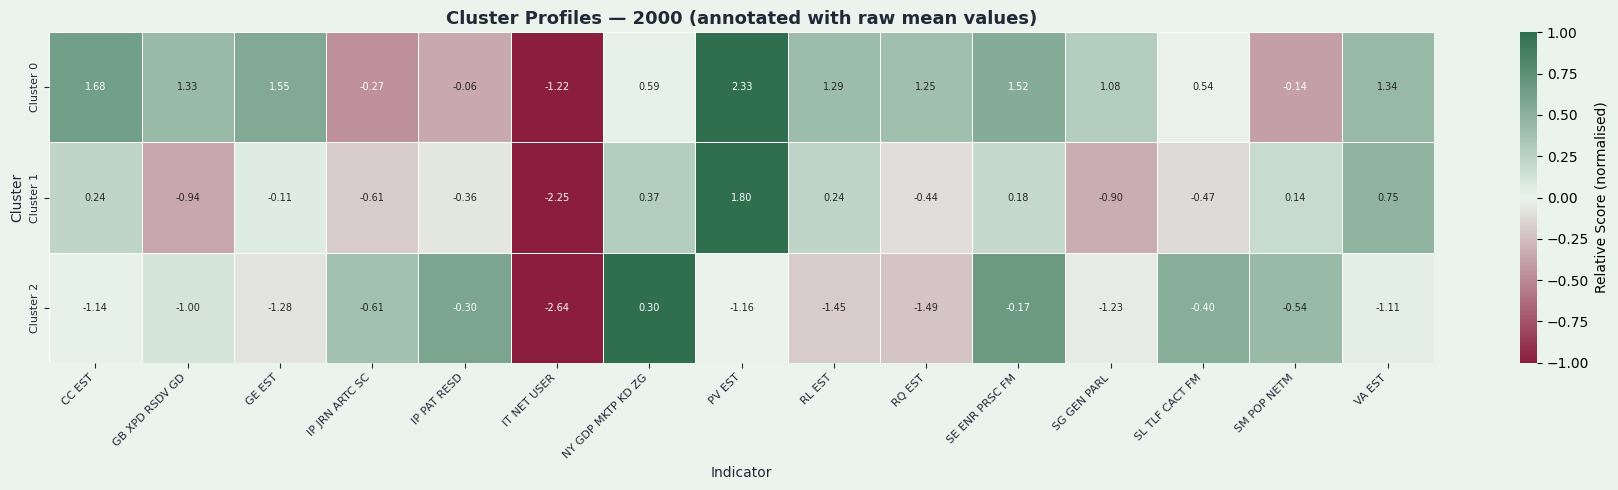

In [19]:
year_focus = 2000

df_yr = df_profile[
    (df_profile["year"] == year_focus) &
    (df_profile["Ambiguous"] == False)
]

profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()

# Reorder clusters for final thesis presentation:
# Cluster 0 = Weak Institutional Framework
# Cluster 1 = Transitional Governance
# Cluster 2 = Consolidated Governance
profile = profile.reindex([1, 2, 0])

profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]
profile.index = ["Cluster 0", "Cluster 1", "Cluster 2"]

profile_norm = pd.DataFrame(
    MinMaxScaler(feature_range=(-1, 1)).fit_transform(profile.T).T,
    index=profile.index,
    columns=profile.columns
)

fig, ax = plt.subplots(figsize=(18, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(
    profile_norm,
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    annot=profile.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Relative Score (normalised)"}
)

ax.set_title(
    f"Cluster Profiles — {year_focus} (annotated with raw mean values)",
    color=TEXT,
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Indicator", color=TEXT, fontsize=10)
ax.set_ylabel("Cluster", color=TEXT, fontsize=10)
ax.tick_params(colors=TEXT, labelsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Heatmap of average indicator values by cluster in 2023
</p>
</div>

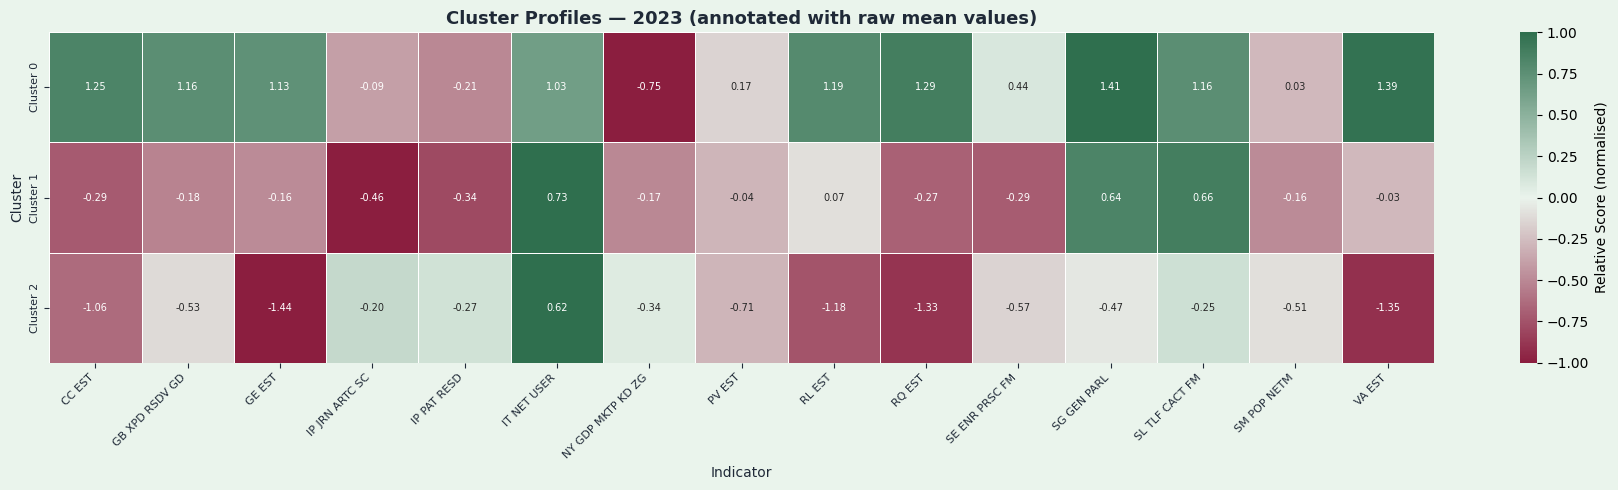

In [20]:
year_focus = 2023

df_yr = df_profile[
    (df_profile["year"] == year_focus) &
    (df_profile["Ambiguous"] == False)
]

profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()

# Reorder clusters for final thesis presentation:
# Cluster 0 = Weak Institutional Framework
# Cluster 1 = Transitional Governance
# Cluster 2 = Consolidated Governance
profile = profile.reindex([1, 2, 0])

profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]
profile.index = ["Cluster 0", "Cluster 1", "Cluster 2"]

profile_norm = pd.DataFrame(
    MinMaxScaler(feature_range=(-1, 1)).fit_transform(profile.T).T,
    index=profile.index,
    columns=profile.columns
)

fig, ax = plt.subplots(figsize=(18, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(
    profile_norm,
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    annot=profile.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Relative Score (normalised)"}
)

ax.set_title(
    f"Cluster Profiles — {year_focus} (annotated with raw mean values)",
    color=TEXT,
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Indicator", color=TEXT, fontsize=10)
ax.set_ylabel("Cluster", color=TEXT, fontsize=10)
ax.tick_params(colors=TEXT, labelsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Heatmap of average indicator values by cluster in 2030
</p>
</div>

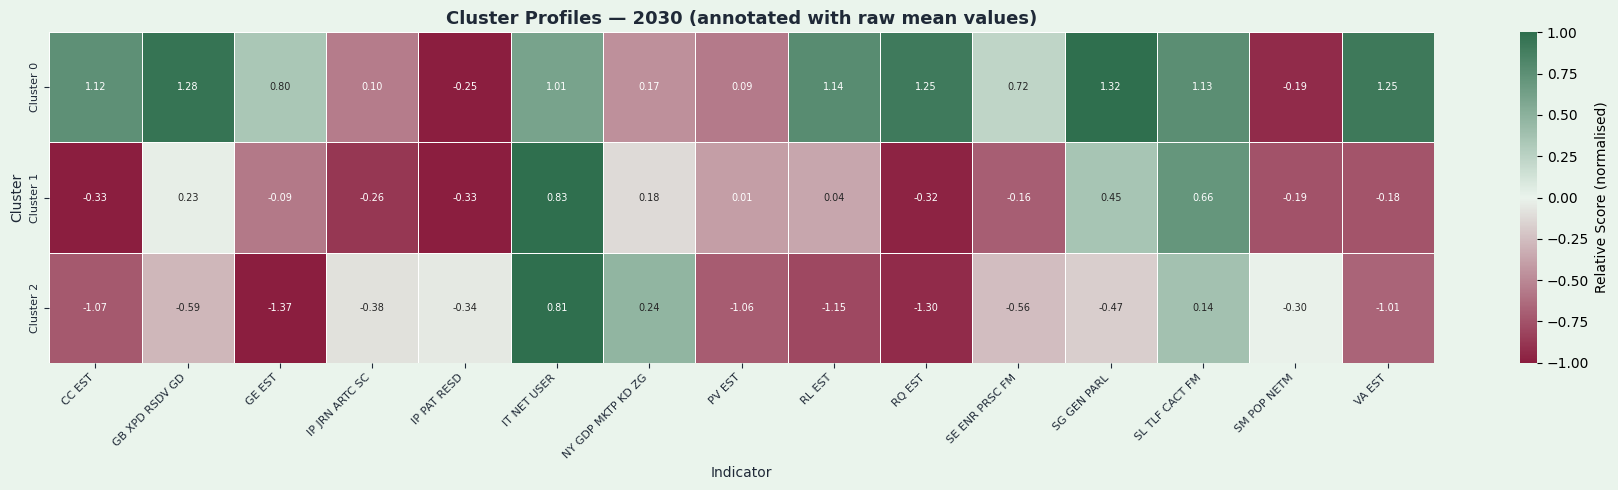

In [21]:
year_focus = 2030

df_yr = df_profile[
    (df_profile["year"] == year_focus) &
    (df_profile["Ambiguous"] == False)
]

profile = df_yr.groupby("Cluster")[INDICATOR_COLS].mean()

# Reorder clusters for final thesis presentation:
# Cluster 0 = Weak Institutional Framework
# Cluster 1 = Transitional Governance
# Cluster 2 = Consolidated Governance
profile = profile.reindex([1, 2, 0])

profile.columns = [c.replace(".ZS", "").replace(".", " ") for c in profile.columns]
profile.index = ["Cluster 0", "Cluster 1", "Cluster 2"]

profile_norm = pd.DataFrame(
    MinMaxScaler(feature_range=(-1, 1)).fit_transform(profile.T).T,
    index=profile.index,
    columns=profile.columns
)

fig, ax = plt.subplots(figsize=(18, 5), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(
    profile_norm,
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    annot=profile.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Relative Score (normalised)"}
)

ax.set_title(
    f"Cluster Profiles — {year_focus} (annotated with raw mean values)",
    color=TEXT,
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Indicator", color=TEXT, fontsize=10)
ax.set_ylabel("Cluster", color=TEXT, fontsize=10)
ax.tick_params(colors=TEXT, labelsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
8. Evolution of Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Comparative heatmap of cluster profiles in 2000, 2023, and 2030
</p>
</div>

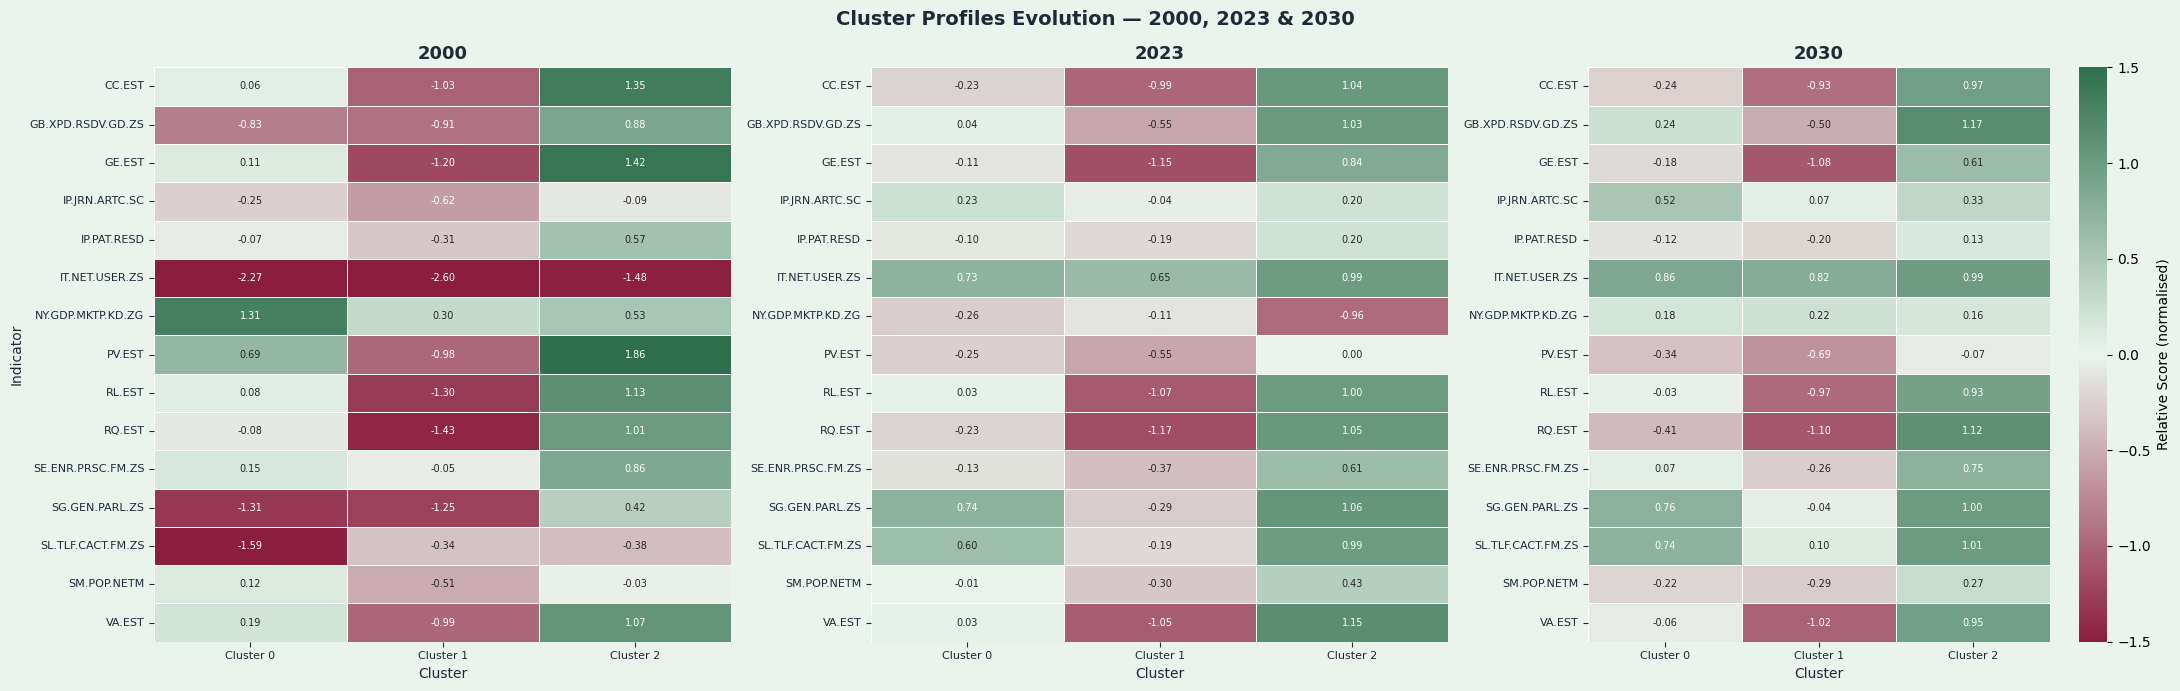

In [22]:
years_focus = [2000, 2023, 2030]
profiles = {}

for yr in years_focus:
    df_temp = df_xy[df_xy["year"] == yr].merge(
        fuzzy_all[fuzzy_all["year"] == yr][["Country Code", "Cluster"]],
        on="Country Code"
    )

    profile = df_temp.groupby("Cluster")[INDICATOR_COLS].mean().round(2)

    # Final order for thesis:
    # Cluster 0 = Consolidated
    # Cluster 1 = Transitional
    # Cluster 2 = Weak
    profile = profile.reindex([2, 0, 1])

    profile.index = ["Cluster 0", "Cluster 1", "Cluster 2"]
    profiles[yr] = profile

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG)

for ax, yr in zip(axes, years_focus):
    ax.set_facecolor(BG)

    sns.heatmap(
        profiles[yr].T,
        ax=ax,
        cmap=custom_cmap,
        center=0,
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        cbar=ax == axes[-1],
        cbar_kws={"label": "Relative Score (normalised)"},
        vmin=-1.5,
        vmax=1.5
    )

    ax.set_title(f"{yr}", color=TEXT, fontsize=13, fontweight="bold")
    ax.set_xlabel("Cluster", color=TEXT, fontsize=10)
    ax.set_ylabel("Indicator" if ax == axes[0] else "", color=TEXT, fontsize=10)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.set_xticklabels(["Cluster 0", "Cluster 1", "Cluster 2"], rotation=0)

fig.suptitle(
    "Cluster Profiles Evolution — 2000, 2023 & 2030",
    color=TEXT,
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
8. Evolution of Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Radar-chart comparison of cluster profiles in 2000, 2023, and 2030
</p>
</div>

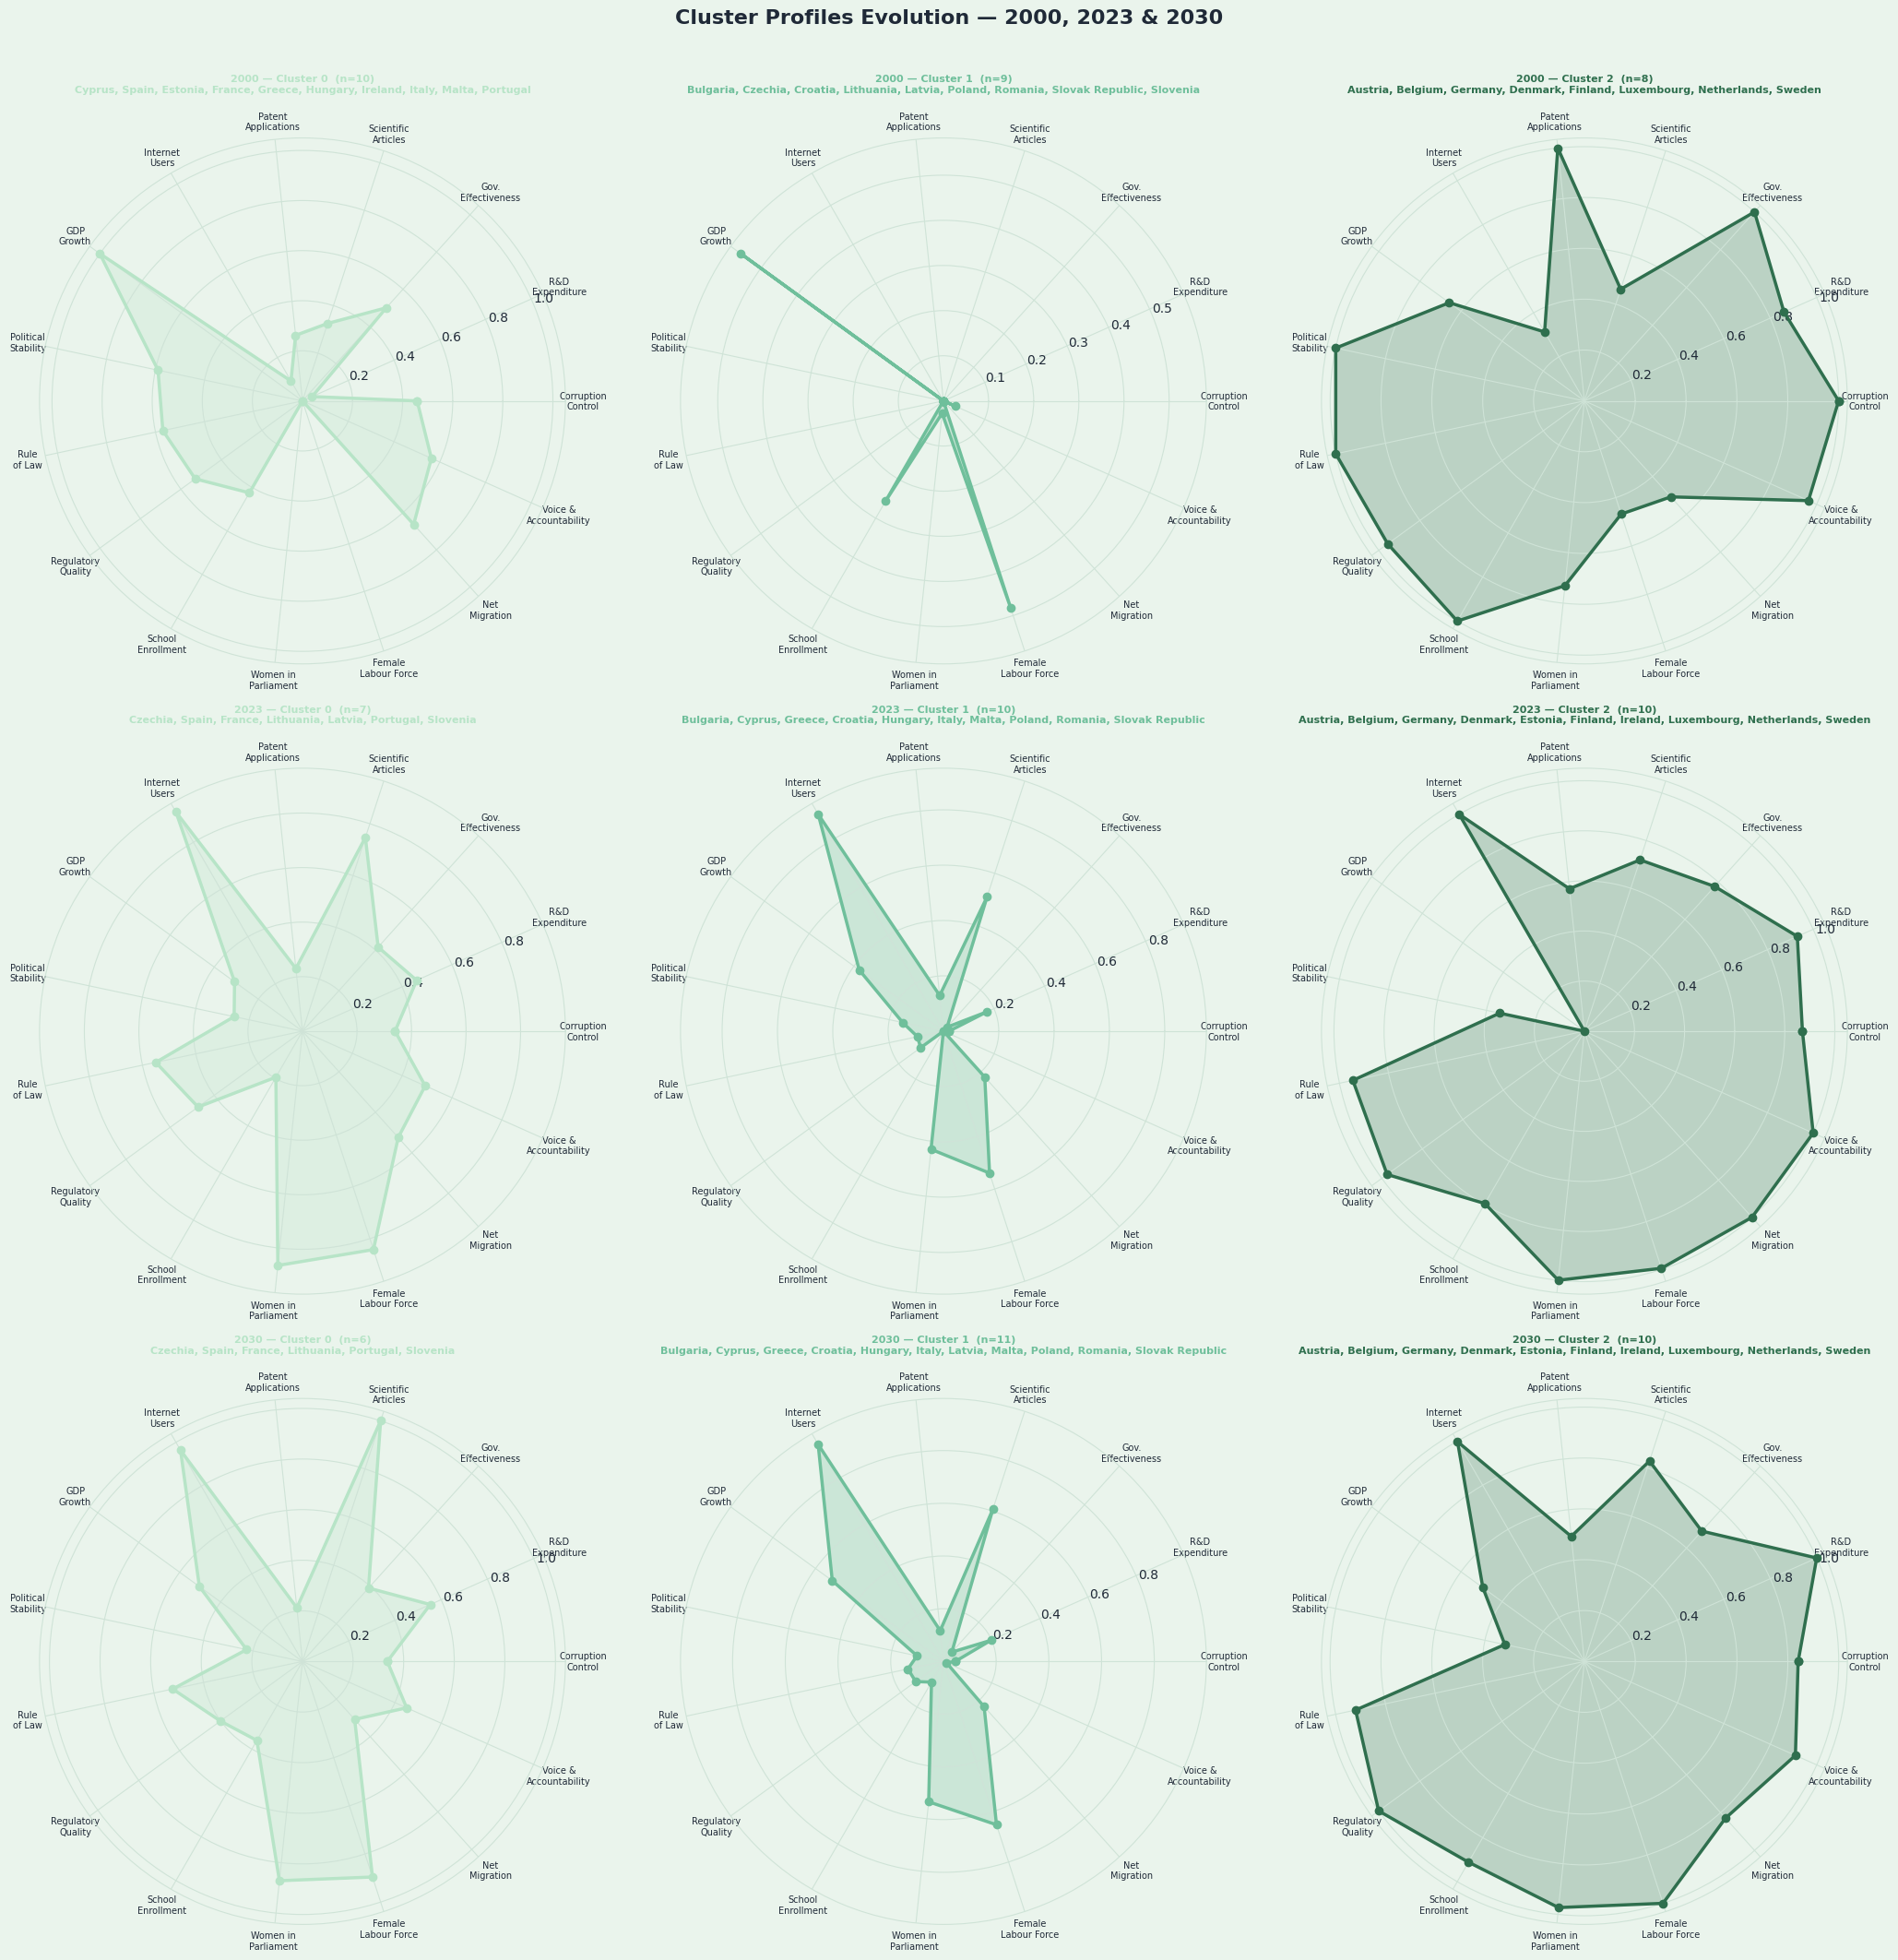

In [16]:
all_profiles = pd.concat([
    df_xy[df_xy["year"] == y]
    .merge(
        fuzzy_all[fuzzy_all["year"] == y][["Country Code", "Cluster"]],
        on="Country Code"
    )
    .groupby("Cluster")[INDICATOR_COLS]
    .mean()
    for y in [2000, 2023, 2030]
])

radar_scaler = MinMaxScaler()
radar_scaler.fit(all_profiles)

ind_labels = {
    "CC.EST": "Corruption\nControl",
    "GB.XPD.RSDV.GD.ZS": "R&D\nExpenditure",
    "GE.EST": "Gov.\nEffectiveness",
    "IP.JRN.ARTC.SC": "Scientific\nArticles",
    "IP.PAT.RESD": "Patent\nApplications",
    "IT.NET.USER.ZS": "Internet\nUsers",
    "NY.GDP.MKTP.KD.ZG": "GDP\nGrowth",
    "PV.EST": "Political\nStability",
    "RL.EST": "Rule\nof Law",
    "RQ.EST": "Regulatory\nQuality",
    "SE.ENR.PRSC.FM.ZS": "School\nEnrollment",
    "SG.GEN.PARL.ZS": "Women in\nParliament",
    "SL.TLF.CACT.FM.ZS": "Female\nLabour Force",
    "SM.POP.NETM": "Net\nMigration",
    "VA.EST": "Voice &\nAccountability",
}

labels = [ind_labels.get(c, c) for c in INDICATOR_COLS]
N = len(INDICATOR_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    3, 3,
    figsize=(21, 21),
    subplot_kw=dict(polar=True),
    facecolor=BG
)

fig.suptitle(
    "Cluster Profiles Evolution — 2000, 2023 & 2030",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    y=1.01
)

for row_idx, year in enumerate([2000, 2023, 2030]):
    df_year = df_xy[df_xy["year"] == year].merge(
        fuzzy_all[fuzzy_all["year"] == year][["Country Code", "Cluster"]],
        on="Country Code"
    )

    cluster_profiles_raw = df_year.groupby("Cluster")[INDICATOR_COLS].mean()

    cluster_profiles = pd.DataFrame(
        radar_scaler.transform(cluster_profiles_raw),
        index=cluster_profiles_raw.index,
        columns=INDICATOR_COLS
    )

    for col_idx in range(N_CLUSTERS):
        ax = axes[row_idx][col_idx]
        ax.set_facecolor(BG)

        if col_idx not in cluster_profiles.index:
            ax.set_visible(False)
            continue

        values = cluster_profiles.loc[col_idx].tolist()
        values += values[:1]

        color = CLUSTER_COLORS[col_idx]
        n_countries = (fuzzy_all[fuzzy_all["year"] == year]["Cluster"] == col_idx).sum()
        countries_list = df_year[df_year["Cluster"] == col_idx]["Country Name"].tolist()

        ax.plot(angles, values, "o-", linewidth=2.5, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)
        ax.axhline(y=0, color="gray", lw=0.8, linestyle="--", alpha=0.5)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=7, color=TEXT)
        ax.tick_params(colors=TEXT)
        ax.spines["polar"].set_color("#CFE3D7")
        ax.grid(color="#CFE3D7", linestyle="-", linewidth=0.8)

        ax.set_title(
            f"{year} — Cluster {col_idx}  (n={n_countries})\n" + ", ".join(countries_list),
            size=8,
            fontweight="bold",
            color=color,
            pad=15
        )

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
8. Evolution of Cluster Profiles
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Indicators that most strongly differentiate the clusters in 2030
</p>
</div>

Top 10 indicadores que mais diferenciam os clusters:
     Indicator  F_statistic      p_value
        RL EST   140.015383 4.814108e-09
        GE EST    58.021573 6.775627e-07
        PV EST    41.805723 3.908662e-06
   SG GEN PARL    39.310663 5.391443e-06
        RQ EST    32.453080 1.443181e-05
        VA EST    29.448901 2.351207e-05
        CC EST    29.228839 2.440717e-05
   IT NET USER    14.021034 7.244167e-04
GB XPD RSDV GD    11.579771 1.580623e-03
   IP PAT RESD     5.974262 1.582760e-02


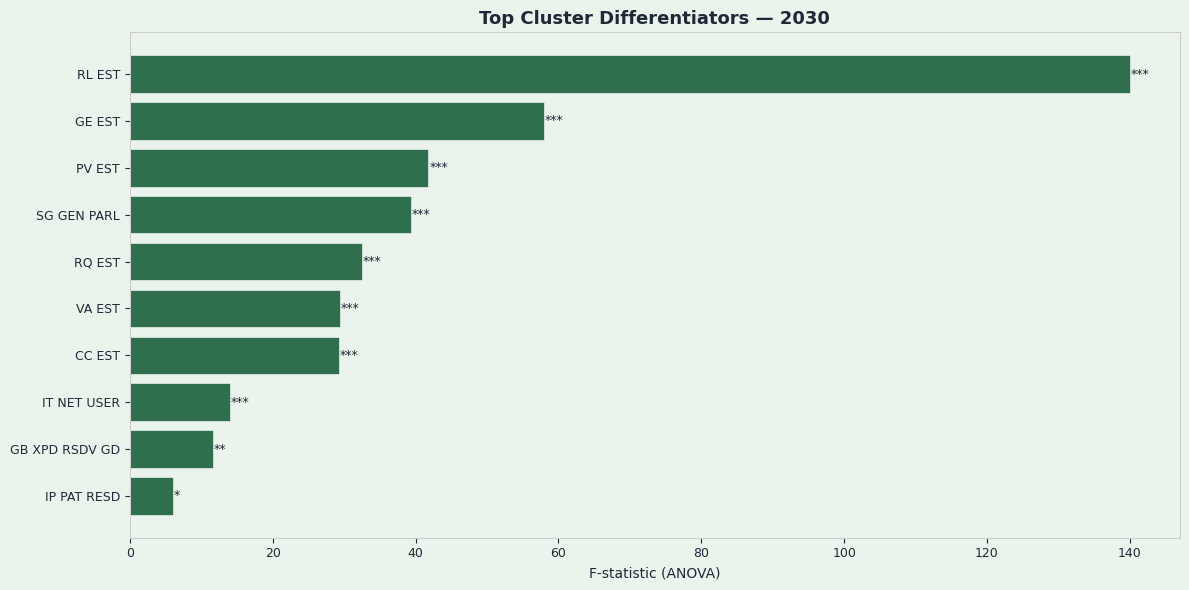

In [17]:
year_focus = 2030

df_yr = df_profile[
    (df_profile["year"] == year_focus) &
    (df_profile["Ambiguous"] == False)
]

anova_results = []
for col in INDICATOR_COLS:
    groups = [
        df_yr[df_yr["Cluster"] == k][col].dropna().values
        for k in range(N_CLUSTERS)
    ]
    if all(len(g) > 1 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        anova_results.append({
            "Indicator": col.replace(".ZS", "").replace(".", " "),
            "F_statistic": f_stat,
            "p_value": p_val
        })

df_anova = pd.DataFrame(anova_results).sort_values("F_statistic", ascending=False)

print("Top 10 indicadores que mais diferenciam os clusters:")
print(df_anova.head(10).to_string(index=False))

top10 = df_anova.head(10)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(
    top10["Indicator"][::-1],
    top10["F_statistic"][::-1],
    color=ACCENT,
    edgecolor="white",
    linewidth=0.4
)

for i, (_, row) in enumerate(top10[::-1].iterrows()):
    stars = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*"
    ax.text(row["F_statistic"] + 0.1, i, stars, va="center", color=TEXT, fontsize=9)

ax.set_xlabel("F-statistic (ANOVA)", color=TEXT, fontsize=10)
ax.set_title(f"Top Cluster Differentiators — {year_focus}",
             color=TEXT, fontsize=13, fontweight="bold")
ax.tick_params(colors=TEXT, labelsize=9)

for spine in ax.spines.values():
    spine.set_color("#cccccc")

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. Cluster Transition Analysis
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Comparison of cluster membership between 2000 and 2030
</p>
</div>

In [18]:
comp = (
    fuzzy_all[fuzzy_all["year"] == 2000][["Country Code", "Country Name", "Cluster"]]
    .rename(columns={"Cluster": "Cluster_2000"})
    .merge(
        fuzzy_all[fuzzy_all["year"] == 2030][["Country Code", "Cluster"]]
        .rename(columns={"Cluster": "Cluster_2030"}),
        on="Country Code"
    )
)

comp["Changed"] = comp["Cluster_2000"] != comp["Cluster_2030"]

print(f"Countries changing cluster 2000→2030: {comp['Changed'].sum()} / {len(comp)}")

comp.sort_values(["Changed", "Country Code"], ascending=[False, True]).reset_index(drop=True)

Countries changing cluster 2000→2030: 10 / 27


Indicator Code,Country Code,Country Name,Cluster_2000,Cluster_2030,Changed
0,CYP,Cyprus,0,1,True
1,CZE,Czechia,1,0,True
2,EST,Estonia,0,2,True
3,GRC,Greece,0,1,True
4,HUN,Hungary,0,1,True
5,IRL,Ireland,0,2,True
6,ITA,Italy,0,1,True
7,LTU,Lithuania,1,0,True
8,MLT,Malta,0,1,True
9,SVN,Slovenia,1,0,True


In [19]:
changed = comp[comp["Changed"] == True].copy()
display(changed)

Indicator Code,Country Code,Country Name,Cluster_2000,Cluster_2030,Changed
3,CYP,Cyprus,0,1,True
4,CZE,Czechia,1,0,True
8,EST,Estonia,0,2,True
11,GRC,Greece,0,1,True
13,HUN,Hungary,0,1,True
14,IRL,Ireland,0,2,True
15,ITA,Italy,0,1,True
16,LTU,Lithuania,1,0,True
19,MLT,Malta,0,1,True
25,SVN,Slovenia,1,0,True


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. Cluster Transition Analysis
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Transition matrices for the observed and projected periods
</p>
</div>

In [21]:
def transition_matrix(df, year_start, year_end, label):
    start = df[df["year"] == year_start][["Country Code", "Cluster"]] \
        .rename(columns={"Cluster": "Cluster_Start"})
    end = df[df["year"] == year_end][["Country Code", "Cluster"]] \
        .rename(columns={"Cluster": "Cluster_End"})

    merged = start.merge(end, on="Country Code")

    matrix = pd.crosstab(
        merged["Cluster_Start"],
        merged["Cluster_End"],
        rownames=["From"],
        colnames=["To"]
    )

    matrix_pct = matrix.div(matrix.sum(axis=1), axis=0).round(2)

    print(f"\n{'='*40}")
    print(f"  {label}  ({year_start} → {year_end})")
    print(f"{'='*40}")
    print("Counts:")
    print(matrix)
    print("\nRow proportions:")
    print(matrix_pct)

    changed_local = merged[merged["Cluster_Start"] != merged["Cluster_End"]]
    print(f"\nCountries that changed: {len(changed_local)} / {len(merged)}")

    if len(changed_local) > 0:
        print(
            changed_local.merge(
                fuzzy_all[["Country Code", "Country Name"]].drop_duplicates(),
                on="Country Code"
            )[["Country Name", "Cluster_Start", "Cluster_End"]].to_string(index=False)
        )

    return matrix, matrix_pct

matrix_obs, matrix_obs_pct = transition_matrix(fuzzy_all, 2000, 2023, "OBSERVED")
matrix_proj, matrix_proj_pct = transition_matrix(fuzzy_all, 2023, 2030, "PROJECTED")


  OBSERVED  (2000 → 2023)
Counts:
To    0  1  2
From         
0     3  5  2
1     4  5  0
2     0  0  8

Row proportions:
To       0     1    2
From                 
0     0.30  0.50  0.2
1     0.44  0.56  0.0
2     0.00  0.00  1.0

Countries that changed: 11 / 27
Country Name  Cluster_Start  Cluster_End
      Cyprus              0            1
     Czechia              1            0
     Estonia              0            2
      Greece              0            1
     Hungary              0            1
     Ireland              0            2
       Italy              0            1
   Lithuania              1            0
      Latvia              1            0
       Malta              0            1
    Slovenia              1            0

  PROJECTED  (2023 → 2030)
Counts:
To    0   1   2
From           
0     6   1   0
1     0  10   0
2     0   0  10

Row proportions:
To       0     1    2
From                 
0     0.86  0.14  0.0
1     0.00  1.00  0.0
2     0.00  0.00  1.

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. Cluster Transition Analysis
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Heatmap representation of observed and projected transition matrices
</p>
</div>

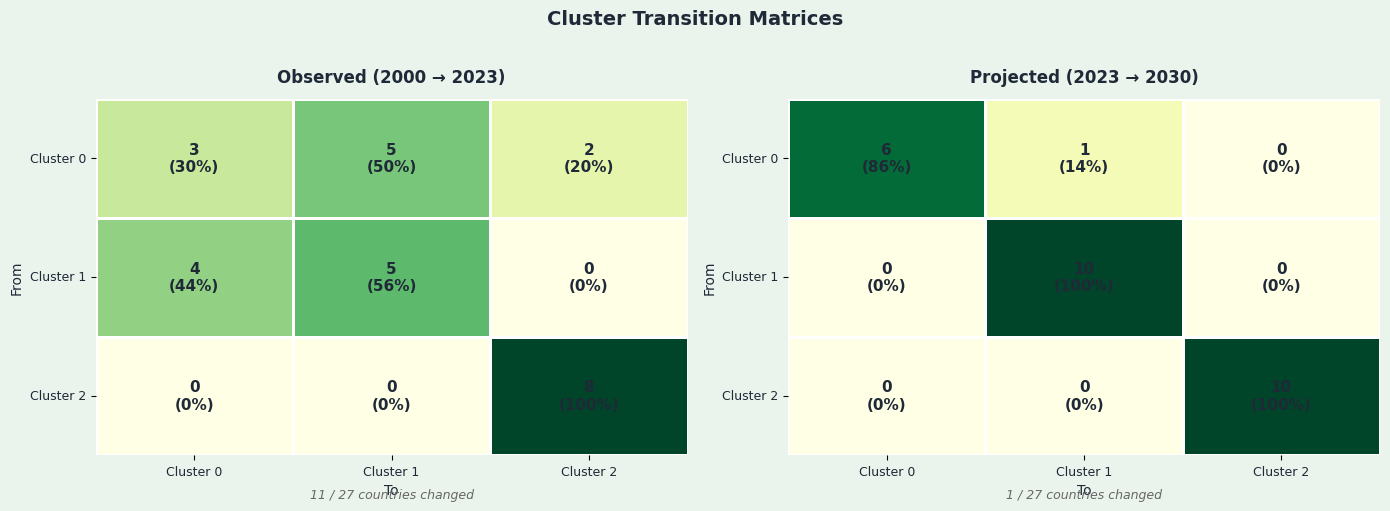

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
cluster_labels = ["Cluster 0", "Cluster 1", "Cluster 2"]

datasets = [
    (matrix_obs_pct, matrix_obs, "Observed (2000 → 2023)", "11 / 27 countries changed"),
    (matrix_proj_pct, matrix_proj, "Projected (2023 → 2030)", "1 / 27 countries changed"),
]

for ax, (pct, counts, title, subtitle) in zip(axes, datasets):
    ax.set_facecolor(BG)
    sns.heatmap(
        pct,
        ax=ax,
        annot=False,
        cmap="YlGn",
        vmin=0, vmax=1,
        linewidths=1,
        linecolor="white",
        cbar=False
    )

    for i in range(len(pct)):
        for j in range(len(pct.columns)):
            n = int(counts.iloc[i, j]) if (i < len(counts) and j < len(counts.columns)) else 0
            pv = pct.iloc[i, j]
            txt = f"{n}\n({int(pv*100)}%)"
            ax.text(j + 0.5, i + 0.5, txt,
                    ha="center", va="center",
                    fontsize=11, color=TEXT, fontweight="bold")

    ax.set_title(title, color=TEXT, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("To", color=TEXT, fontsize=10)
    ax.set_ylabel("From", color=TEXT, fontsize=10)
    ax.set_xticklabels(cluster_labels, color=TEXT, fontsize=9)
    ax.set_yticklabels(cluster_labels, color=TEXT, fontsize=9, rotation=0)
    ax.text(0.5, -0.12, subtitle, transform=ax.transAxes,
            ha="center", fontsize=9, color="#666666", style="italic")

fig.suptitle("Cluster Transition Matrices", color=TEXT, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. Cluster Transition Analysis
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Temporal heatmap of cluster assignments across countries, 2000–2030
</p>
</div>

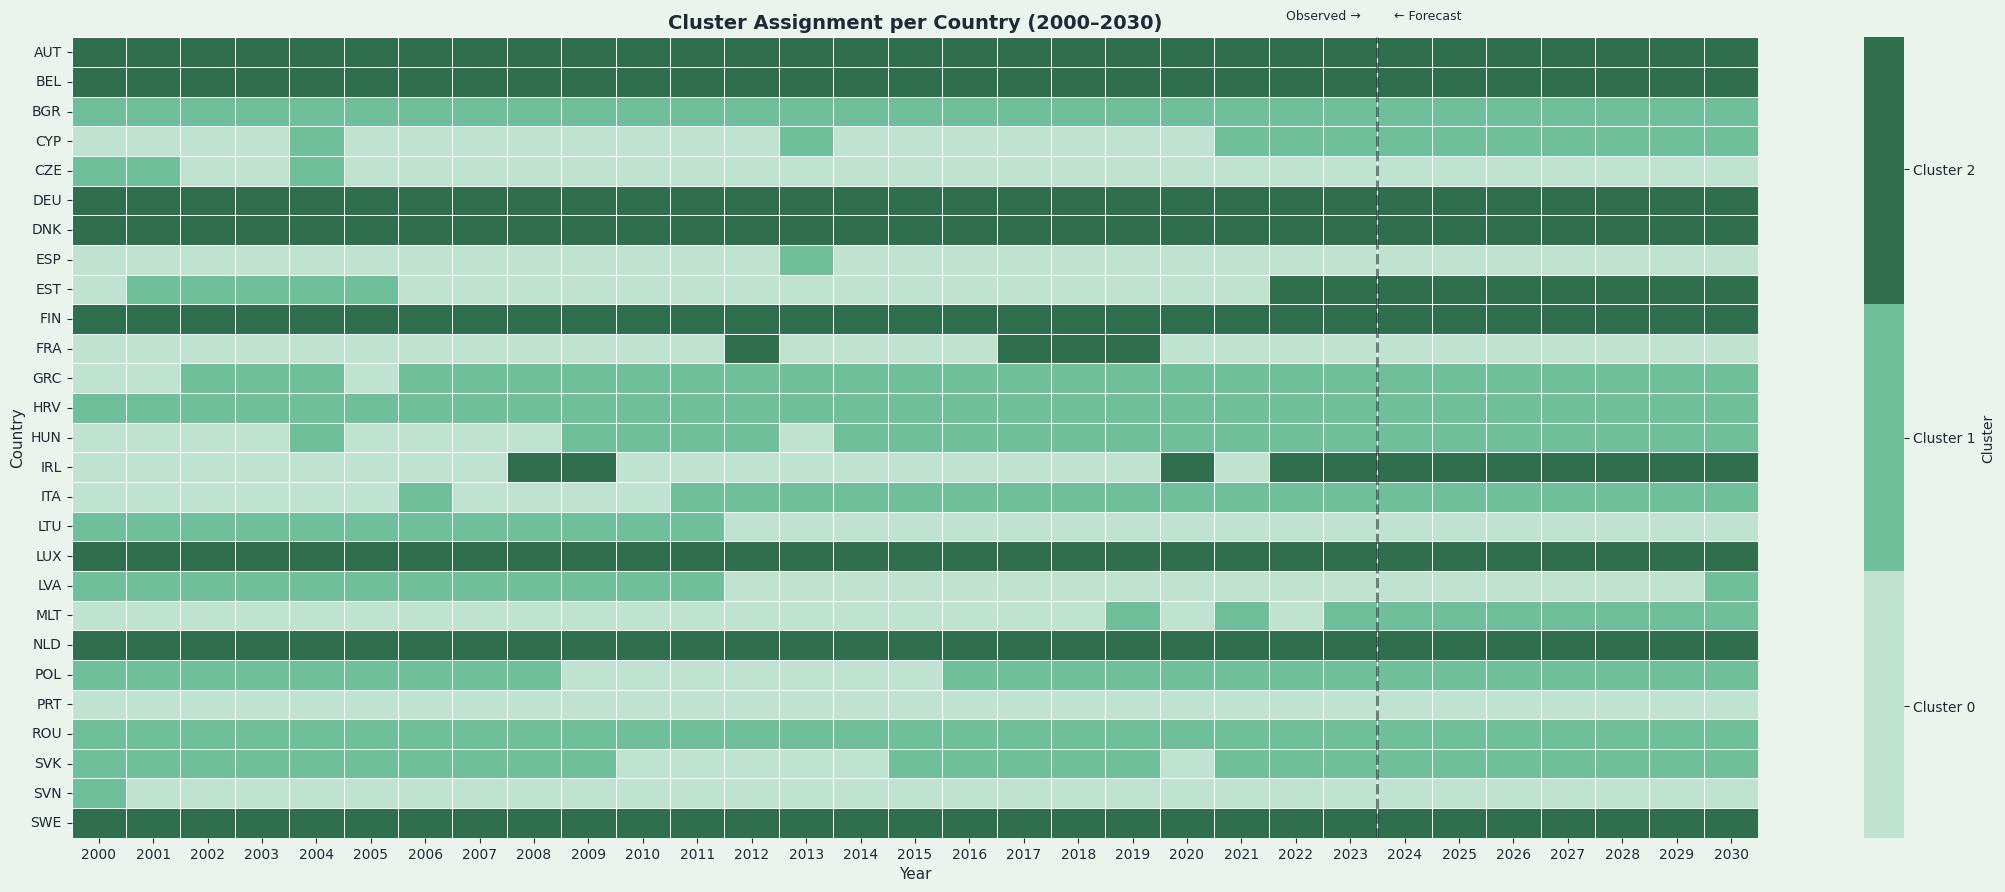

In [23]:
CLUSTER_COLORS = ["#BFE3D0", "#6FBF9B", ACCENT]

pivot_cluster = fuzzy_all.pivot_table(
    index="Country Code",
    columns="year",
    values="Cluster"
)

cmap_clusters = ListedColormap(CLUSTER_COLORS)

fig, ax = plt.subplots(figsize=(22, 9), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(
    pivot_cluster,
    cmap=cmap_clusters,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Cluster", "ticks": [0.33, 1.0, 1.67]},
    vmin=0, vmax=2
)

cbar = ax.collections[0].colorbar
cbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2"])
cbar.ax.yaxis.label.set_color(TEXT)
cbar.ax.tick_params(colors=TEXT)

forecast_idx = list(pivot_cluster.columns).index(2024)
ax.axvline(x=forecast_idx, color=TEXT, lw=2, linestyle="--", alpha=0.6)
ax.text(forecast_idx - 0.3, -0.6, "Observed →", ha="right", fontsize=9, color=TEXT)
ax.text(forecast_idx + 0.3, -0.6, "← Forecast", ha="left", fontsize=9, color=TEXT)

ax.set_title("Cluster Assignment per Country (2000–2030)", color=TEXT, fontweight="bold", fontsize=14)
ax.set_xlabel("Year", color=TEXT, fontsize=11)
ax.set_ylabel("Country", color=TEXT, fontsize=11)
ax.tick_params(colors=TEXT)

plt.tight_layout()
plt.show()

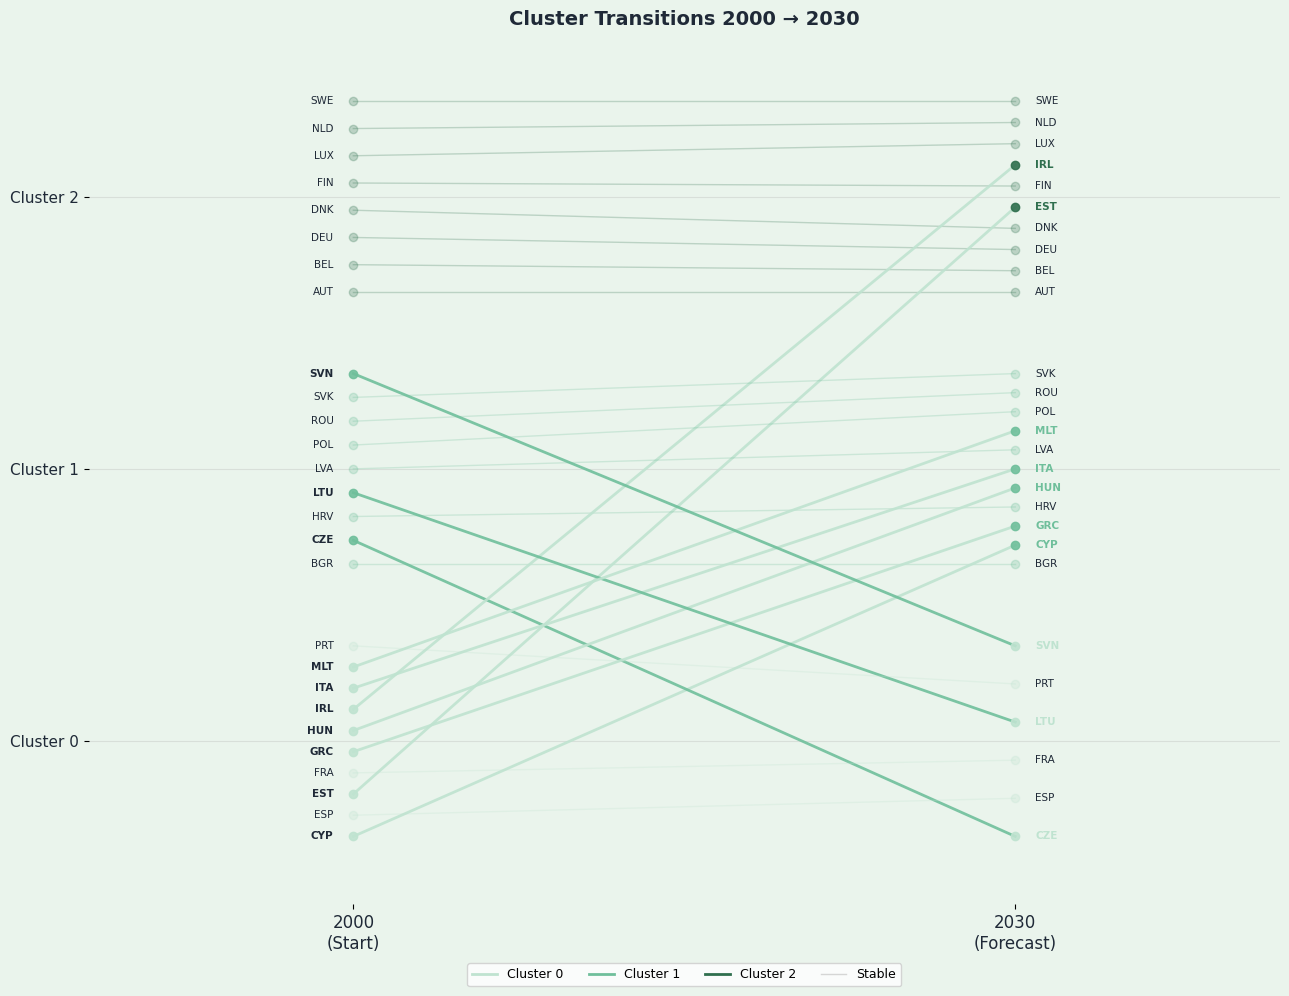

In [24]:
fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
ax.set_facecolor(BG)
np.random.seed(42)

def jitter_positions(comp_df, cluster_col):
    positions = {}
    for cluster in sorted(comp_df[cluster_col].unique()):
        countries = comp_df[comp_df[cluster_col] == cluster]["Country Code"].tolist()
        n = len(countries)
        offsets = np.linspace(-0.35, 0.35, n)
        for country, offset in zip(countries, offsets):
            positions[country] = cluster + offset
    return positions

pos_2000 = jitter_positions(comp, "Cluster_2000")
pos_2030 = jitter_positions(comp, "Cluster_2030")

for _, row in comp.iterrows():
    code = row["Country Code"]
    c1, c2 = int(row["Cluster_2000"]), int(row["Cluster_2030"])
    changed_flag = row["Changed"]
    y1 = pos_2000[code]
    y2 = pos_2030[code]
    color = CLUSTER_COLORS[c1]
    lw = 2 if changed_flag else 1
    alpha = 0.9 if changed_flag else 0.25

    ax.plot([0, 1], [y1, y2], "-", color=color, lw=lw, alpha=alpha)
    ax.plot(0, y1, "o", color=color, markersize=6, alpha=alpha)
    ax.plot(1, y2, "o", color=CLUSTER_COLORS[c2], markersize=6, alpha=alpha)

    ax.text(-0.03, y1, code, ha="right", va="center", fontsize=7.5,
            color=TEXT, fontweight="bold" if changed_flag else "normal")
    ax.text(1.03, y2, code, ha="left", va="center", fontsize=7.5,
            color=CLUSTER_COLORS[c2] if changed_flag else TEXT,
            fontweight="bold" if changed_flag else "normal")

ax.set_xticks([0, 1])
ax.set_xticklabels(["2000\n(Start)", "2030\n(Forecast)"], fontsize=12, color=TEXT)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Cluster 0", "Cluster 1", "Cluster 2"], fontsize=11, color=TEXT)
ax.set_title("Cluster Transitions 2000 → 2030", fontweight="bold", fontsize=14, color=TEXT)
ax.set_xlim(-0.4, 1.4)
ax.set_ylim(-0.6, 2.6)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

legend_elements = [
    Line2D([0], [0], color=CLUSTER_COLORS[0], lw=2, label="Cluster 0"),
    Line2D([0], [0], color=CLUSTER_COLORS[1], lw=2, label="Cluster 1"),
    Line2D([0], [0], color=CLUSTER_COLORS[2], lw=2, label="Cluster 2"),
    Line2D([0], [0], color="gray", lw=1, alpha=0.3, label="Stable"),
]

ax.legend(handles=legend_elements, loc="upper center",
          bbox_to_anchor=(0.5, -0.06), ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. Cluster Transition Analysis
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Sigma-convergence of cluster membership dispersion, 2000–2030
</p>
</div>

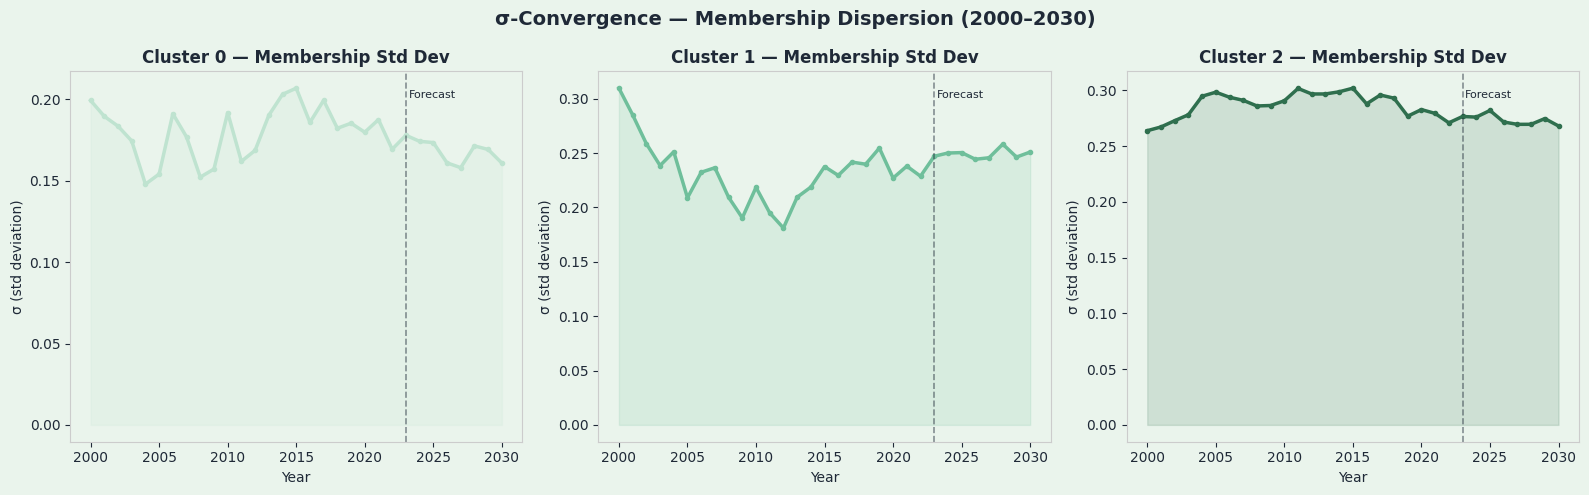

Cluster 0 — σ 2000: 0.199 | σ 2023: 0.178 | σ 2030: 0.161
Cluster 1 — σ 2000: 0.310 | σ 2023: 0.247 | σ 2030: 0.251
Cluster 2 — σ 2000: 0.264 | σ 2023: 0.277 | σ 2030: 0.268


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

for k, ax in enumerate(axes):
    sigma = fuzzy_all.groupby("year")[f"Membership_{k}"].std().reset_index()
    sigma.columns = ["year", "std"]

    ax.set_facecolor(BG)
    ax.plot(sigma["year"], sigma["std"], color=CLUSTER_COLORS[k], lw=2.5, marker="o", markersize=3)
    ax.fill_between(sigma["year"], sigma["std"], alpha=0.15, color=CLUSTER_COLORS[k])
    ax.axvline(x=2023, color=TEXT, lw=1.2, linestyle="--", alpha=0.5)
    ax.text(2023.2, sigma["std"].max() * 0.97, "Forecast", color=TEXT, fontsize=8)

    ax.set_title(f"Cluster {k} — Membership Std Dev", color=TEXT, fontweight="bold")
    ax.set_xlabel("Year", color=TEXT)
    ax.set_ylabel("σ (std deviation)", color=TEXT)
    ax.tick_params(colors=TEXT)

    for spine in ax.spines.values():
        spine.set_color("#cccccc")

fig.suptitle("σ-Convergence — Membership Dispersion (2000–2030)",
             color=TEXT, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for k in range(N_CLUSTERS):
    sigma = fuzzy_all.groupby("year")[f"Membership_{k}"].std()
    print(f"Cluster {k} — σ 2000: {sigma[2000]:.3f} | σ 2023: {sigma[2023]:.3f} | σ 2030: {sigma[2030]:.3f}")

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
10. Robustness Check
</h2>
<p style="color:#444; font-size:14px; margin-top:6px;">
Comparison between the annual clustering solution and the global clustering solution
</p>
</div>

In [26]:
X_all = df_xy[INDICATOR_COLS].values.astype(float)

col_means = np.nanmean(X_all, axis=0)
inds = np.where(np.isnan(X_all))
X_all[inds] = np.take(col_means, inds[1])

X_all_scaled = StandardScaler().fit_transform(X_all)

cntr_g, u_g, *_ = fuzz.cluster.cmeans(
    X_all_scaled.T,
    c=N_CLUSTERS,
    m=M,
    error=0.005,
    maxiter=1000,
    init=None
)

cluster_labels_global = np.argmax(u_g, axis=0)
df_xy["Cluster_Global"] = cluster_labels_global

YEAR_REF = 2023

annual_ref = fuzzy_all[fuzzy_all["year"] == YEAR_REF][["Country Code", "Country Name", "Cluster"]].copy()
annual_ref = annual_ref.rename(columns={"Cluster": "Cluster_Annual"})

global_ref = df_xy[df_xy["year"] == YEAR_REF][["Country Code", "Cluster_Global"]].copy()

compare = annual_ref.merge(global_ref, on="Country Code")

print(f"compare shape: {compare.shape}")
print(compare.head(26))

compare shape: (27, 4)
Indicator Code Country Code     Country Name  Cluster_Annual  Cluster_Global
0                       AUT          Austria               2               2
1                       BEL          Belgium               2               2
2                       BGR         Bulgaria               1               0
3                       CYP           Cyprus               1               0
4                       CZE          Czechia               0               1
5                       DEU          Germany               2               2
6                       DNK          Denmark               2               2
7                       ESP            Spain               0               1
8                       EST          Estonia               2               2
9                       FIN          Finland               2               2
10                      FRA           France               0               1
11                      GRC           Greece         

In [27]:
conf = pd.crosstab(compare["Cluster_Annual"], compare["Cluster_Global"])
print("Confusion matrix:")
print(conf)

row_ind, col_ind = linear_sum_assignment(-conf)
mapping = {col_ind[i]: row_ind[i] for i in range(N_CLUSTERS)}
print("Label mapping (global → annual):", mapping)

compare["Cluster_Global_Aligned"] = compare["Cluster_Global"].map(mapping)
compare["Match_Aligned"] = compare["Cluster_Global_Aligned"] == compare["Cluster_Annual"]

print(f"\nAgreement after alignment: {compare['Match_Aligned'].sum()} / {len(compare)}")
print()
print(compare[["Country Name", "Cluster_Annual", "Cluster_Global_Aligned", "Match_Aligned"]].to_string(index=False))

Confusion matrix:
Cluster_Global  0  1   2
Cluster_Annual          
0               0  7   0
1               9  1   0
2               0  0  10
Label mapping (global → annual): {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2)}

Agreement after alignment: 26 / 27

   Country Name  Cluster_Annual  Cluster_Global_Aligned  Match_Aligned
        Austria               2                       2           True
        Belgium               2                       2           True
       Bulgaria               1                       1           True
         Cyprus               1                       1           True
        Czechia               0                       0           True
        Germany               2                       2           True
        Denmark               2                       2           True
          Spain               0                       0           True
        Estonia               2                       2           Tru

In [58]:
fuzzy_all.to_csv("../../data/processed/fuzzy_all.csv", index=False)
df_xy.to_csv("../../data/processed/df_xy_pivoted.csv", index=False)

print("Exportado:")
print(f"  fuzzy_all:      {fuzzy_all.shape}")
print(f"  df_xy_pivoted:  {df_xy.shape}")

Exportado:
  fuzzy_all:      (837, 9)
  df_xy_pivoted:  (837, 19)
